In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')


In [2]:
# Check if CUDA is available and set the default device to GPU if it is
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"

# Export DISPLAY to 10.0
os.environ["DISPLAY"] = ":12.0"

In [3]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 
if 0:
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.5])
    ])
else:
    transform = transforms.Compose([
        #transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5,  0.5])
    ])


from plant_tokenizer import PAD_token



import pickle
# Check if the .plk file exists
train_dataset_name = "../data/train_dataset.pkl"
val_dataset_name = "../data/val_dataset.pkl"
if os.path.exists(train_dataset_name):
    if os.path.exists(train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    train_dataset = PlantDataset("../data/generated_renamed", plot=["000", "001", "002",], transform=transform, use_depth=True)
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset("../data/generated_renamed", plot=["003"], transform=transform, use_depth=True)

    with open(train_dataset_name, "wb") as f:
        pickle.dump(train_dataset, f)
    with open(val_dataset_name, "wb") as f:
        pickle.dump(val_dataset, f)

Loading plant dataset from .pkl file


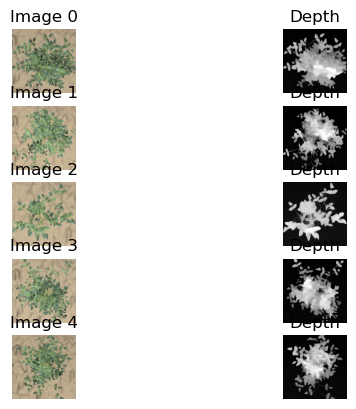

In [4]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000", "001", "002", "003"], transform=transform,dry_run=True,use_depth=False)

import cv2
n = 5
for i in range(n):
    image, vecs, _ = train_dataset[-i-1]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if train_dataset.use_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [5]:
from models.model import ImageToSequenceTransformer


# Initialize model
num_layers =  3 # Default 6
num_heads = 4   # Default 8 
seq_dim = 43 # 43개의 토큰 
seq_embedding_dim = 64 # 
param_dim = 5 + 3 + 2 + 4
param_embedding_dim = 64

model = ImageToSequenceTransformer(seq_embedding_dim=seq_embedding_dim, 
                                   param_embedding_dim=param_embedding_dim,
                                   num_layers=num_layers, num_heads=num_heads, 
                                   num_tokens=seq_dim, num_params=param_dim,
                                   decoder_only=True,
                                   use_depth=True)

# Test
if 0:
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    for _,_,_ in train_dataloader:
        break
# Test model
if 0:
    image_paths, vectors, lengths = next(iter(train_dataloader))
    output = model(image_paths, vectors)
model = model.to(device)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
labes_loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
model.to(device)

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

In [6]:
def collate_fn(batch):
    images, vectors, lengths = zip(*batch)
    max_length = max(lengths)
    # Check if the vectors are 1 dimensional
    if len(vectors[0].shape) == 1:
        vectors_padded = np.ones((len(vectors), max_length), dtype=int) * PAD_token
    else:
        vectors_padded = np.ones((len(vectors), max_length, 1+5+3+2+4)) * PAD_token
        if 0:
            # Reset param space
            vectors_padded[:,:,1:] = 0
        
    for i, vector in enumerate(vectors):
        end = lengths[i]
        vectors_padded[i, :end] = vector
    images = torch.stack(images)
    vectors_padded = torch.tensor(vectors_padded,dtype=torch.float32)
    return images, vectors_padded, lengths

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [7]:
train_loss_list, validation_loss_list = [], []
pretrained = True
#model_save_path = '../models/checkpoints/ViT_Transformer_rgbd_params_est_param_20240703.pth'
model_save_path = '../models/checkpoints/ViT_Transformer_rgbd_params_est_param.pth'
if pretrained:
    model.load_state_dict(torch.load(model_save_path))

Total 390 images and plant strings loaded


/tmp/ipykernel_3776063/1134849790.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(device)


Debug: false
Grow: false
View height0m
Tile file: black.png
Plant string file: /home/lion397/codes/Image2PlantArchitecture/src/plant_string.txt
Initializing graphics...done.
writing JPEG image: output/plant_string_top.jpeg


(-0.5, 223.5, 223.5, -0.5)

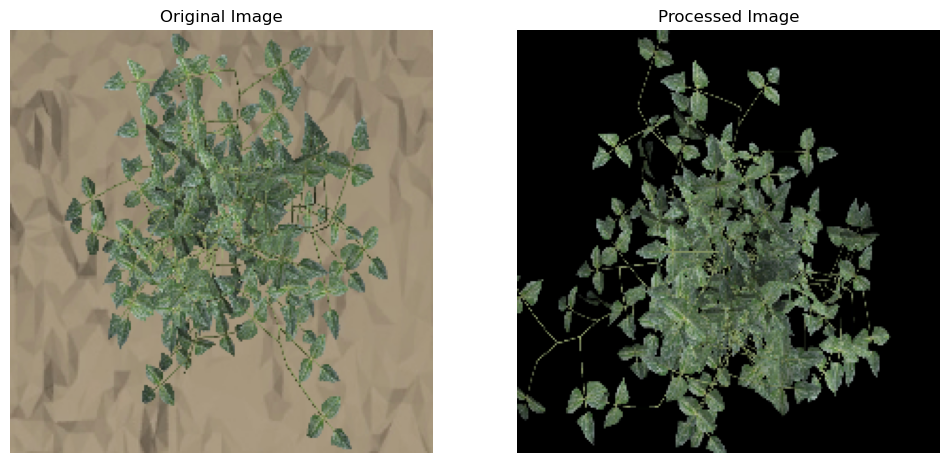

In [8]:
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token, token2vec
from utils import get_tgt_mask

def plot_image(image):
    # Plot the image
    image_vis = image.permute(0, 2, 3, 1).cpu().numpy()
    img_rgb = image_vis[0, :, :, :3]
    img_depth = image_vis[0, :, :, 3]
    # Normalize img_rgb to 0-255 per channels
    for i in range(3):
        img_rgb[:, :, i] = (img_rgb[:, :, i] - img_rgb[:, :, i].min()) / (img_rgb[:, :, i].max() - img_rgb[:, :, i].min()) * 255
    img_rgb = img_rgb.astype(np.uint8)
    # BGR to RGB
    # img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.subplot(1, 2, 2)
    plt.imshow(img_depth)
    plt.show()


def predict(model, images, out, max_length=15, SOS_token=2, EOS_token=3):
    # Assuming 'device' is defined elsewhere in your code and is a CUDA device.
    y_input = torch.tensor(params_SOS_token_padded, dtype=torch.float32)
    
    # Change to 1,1,15
    y_input = y_input.unsqueeze(0).unsqueeze(0)
    y_input = y_input.to(device)
    for i in range(max_length):
        # Get source mask
        tgt_mask = get_tgt_mask(y_input.size(1)).to(device)
        
        try:
            with torch.no_grad():
                pred = model(images, y_input, tgt_mask)
        except Exception as e:
            print(e)
            print(f"Error in {i} iteration")
            break
        label_p = pred[:,:,:seq_dim]
        label = label_p.topk(1)[1].view(-1)[-1].item()  # num with highest probability
        params = pred[:,:,seq_dim:]

        # Stop if model predicts end of sentencplant_structure_vit_transformer_withpsudodepth_paramEste
        if label == EOS_token or label == PAD_token:
            break

        # Make next tensor using label and params
        next_item = torch.cat((torch.tensor([[label]], dtype=torch.float32, device=device), params[-1]), dim=1).unsqueeze(0)

        # Concatenate previous input with predicted best word
        y_input = torch.cat((y_input, next_item), dim=1)

    return y_input.squeeze(0).tolist()

model.eval()

#test_dataset = PlantDataset("../data/generated_renamed", plot=["004"],stages=["023"],
                            # transform=transform, use_depth=True, preload=False, process_leaf=False)
test_dataset = PlantDataset("../data/generated_renamed", plot=["004"],stages=["023"],
                            transform=transform, use_depth=True, preload=False, process_leaf=False)
gen_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

for idx, (image, out, lengths) in enumerate(gen_dataloader):
    out = torch.tensor(out).to(device)
    image_paths = image.to(device)

    # Plot the image
    # Draw the image
    image_vis = image.squeeze(0).permute(1,2,0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_vis = img.astype(np.uint8)
    # plt.imshow(image_vis)
    result = predict(model, image_paths, out, max_length=2048, SOS_token=SOS_token, EOS_token=EOS_token)
    # print(f"Example {idx}")
    # print(f"Input Structure: {token2vec(out.squeeze(0).tolist())}")
    # print(f"Input Token: {out.squeeze(0).tolist()}")
    # print(f"Continuation Token: {result}")
    # print(f"Continuation Structure: {token2vec(result)}")
    # print()
    break

# Token to structure
plant_vec = token2vec(result)
# print(plant_vec)
# Plant vec to string
plant_string = vec2string([plant_vec])
# print(plant_string)

# plant_vec to xml
#xml_string = vec2xml(plant_vec)
#print(pretty_print_xml(xml_string))


# print(plant_string)
# Save plant string to text
plant_string_file_name = "plant_string.txt"
with open(plant_string_file_name, "w") as f:
    f.write(plant_string)



# Generate plant image
from plantstring2model import plantstring2model
from image_process import process_leaf_image
import cv2
import matplotlib.pyplot as plt
#p2m = plantstring2model(program_path="PlantString2Model/build",program_name="PlantString2Model",display=":11.0",background_path="dirt.jpg")
p2m = plantstring2model(program_path="PlantString2Model/build",program_name="PlantString2Model",display=":11.0",background_path="black.png")

# Run 
plant_string_file_path = os.path.abspath("./plant_string.txt")
p2m.run(plantstring_path=plant_string_file_path)
generated_image_path = "output/plant_string_top.jpeg"

# Load the image
img = cv2.imread(generated_image_path)
leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img,sqaure_crop=True, thr = 0.2)
# Plot the processed image
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


# Plot the original and processed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Original Image")
axes[0].axis('off')

# Processed image
img = cv2.resize(img,(224,224))
axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Processed Image")
axes[1].axis('off')

In [ ]:
from tqdm.auto import tqdm

model.eval()
gen_dataset = PlantDataset("../data/generated_renamed",transform=transform, use_depth=True, preload=False, process_leaf=True)

# Create a folder
generated_dataset_folder = "../data/generated_dataset_Sep18"
if not os.path.exists(generated_dataset_folder):
    os.makedirs(generated_dataset_folder)

# Create images, plant strings folders
images_folder = os.path.join(generated_dataset_folder, "images")
plant_strings_folder = os.path.join(generated_dataset_folder, "plant_strings")
if not os.path.exists(images_folder):
    os.makedirs(images_folder)
if not os.path.exists(plant_strings_folder):
    os.makedirs(plant_strings_folder)

for idx, (image, out, lengths) in enumerate(tqdm(gen_dataset)):
    image_name = gen_dataset.image_paths[idx]
    name_prefix = os.path.splitext(os.path.basename(image_name))[0]

    # Match dimensions
    out = torch.tensor(out).to(device)
    image_paths = image.to(device)

    out = out.unsqueeze(0)
    image_paths = image_paths.unsqueeze(0)

    # Plot the image
    # Draw the image
    image_vis = image.squeeze(0).permute(1,2,0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_vis = img.astype(np.uint8)

    try:
        # plt.imshow(image_vis)
        result = predict(model, image_paths, out, max_length=2048, SOS_token=SOS_token, EOS_token=EOS_token)

        # Token to structure
        plant_vec = token2vec(result)

        # Plant vec to string
        plant_string = vec2string([plant_vec])
    except Exception as e:
        print(f"Error in {idx} iteration")
        print(e)
        continue

    # Save plant string to text
    plant_string_file_name = f"{name_prefix}.txt"
    plant_string_file_path = os.path.join(plant_strings_folder, plant_string_file_name)
    with open(plant_string_file_path, "w") as f:
        f.write(plant_string)

    # Generate plant imag
    #p2m = plantstring2model(program_path="PlantString2Model/build",program_name="PlantString2Model",display=":11.0",background_path="dirt.jpg")
    p2m = plantstring2model(program_path="PlantString2Model/build",program_name="PlantString2Model",display=":11.0",background_path="black.png")

    # Run
    # convert plant_string_file_path to absolute path
    plant_string_file_path = os.path.abspath(plant_string_file_path)
    p2m.run(plantstring_path=plant_string_file_path)
    generated_image_path = f"output/{name_prefix}_top.jpeg"

    # Copy the image to the images folder
    dest_image_path = os.path.join(images_folder, f"{name_prefix}.jpeg")
    os.system(f"cp {generated_image_path} {dest_image_path}")

Total 7950 images and plant strings loaded


  0%|                                                                                          | 0/7950 [00:00<?, ?it/s]

Debug: false
Grow: false
View height0m
Tile file: black.png
Plant string file: /home/lion397/codes/Image2PlantArchitecture/data/generated_dataset_Sep18/plant_strings/camA_cowpea_003_000_0658781_RGB_00.txt
Initializing graphics...done.


  0%|                                                                                | 1/7950 [00:01<3:10:02,  1.43s/it]

writing JPEG image: output/camA_cowpea_003_000_0658781_RGB_00_top.jpeg
Debug: false
Grow: false
View height0m
Tile file: black.png
Plant string file: /home/lion397/codes/Image2PlantArchitecture/data/generated_dataset_Sep18/plant_strings/camA_cowpea_003_000_0658781_RGB_01.txt
Initializing graphics...done.


...

 12%|█████████▍                                                                    | 957/7950 [21:57<2:41:11,  1.38s/it]

writing JPEG image: output/camA_cowpea_003_002_4439350_RGB_09_top.jpeg
Debug: false
Grow: false
View height0m
Tile file: black.png
Plant string file: /home/lion397/codes/Image2PlantArchitecture/data/generated_dataset_Sep18/plant_strings/camA_cowpea_003_002_4439350_RGB_10.txt
Initializing graphics...done.


 12%|█████████▍                                                                    | 958/7950 [21:58<2:39:25,  1.37s/it]

writing JPEG image: output/camA_cowpea_003_002_4439350_RGB_10_top.jpeg


 13%|█████████▉                                                                   | 1029/7950 [23:35<2:35:10,  1.35s/it]